# Data Visualization Ethics Challenge

In this activity, you’ll work with a simple dataset and examine two deliberately bad charts.  
Each one ignores multiple best practices for ethical and effective visualization.

Your job is to:

1. Review each chart and note at least three issues you see.  
2. Create a new chart (or charts) that present the data clearly, accurately, and honestly.  
3. Include clear labels, a cited data source, and a descriptive but neutral title.

**Remember:** Strong visualizations tell the truth, provide context, and avoid design choices that distort or mislead.


## Step 1: Load the dataset

We’re using a provided CSV file with fictional sales data for a coffee chain.  
No need to modify anything in this cell — just run it so the dataset loads into your notebook.  
Once loaded, take a quick look at the first few rows to get familiar with the columns and values.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

coffee_df = pd.read_csv("fake_coffee_chain_sales.csv")
coffee_df.head()

,Year,Month,Region,Category,Sales,Profit
0,2020,January,East,Espresso,14724,5290.46
1,2020,January,East,Lattes,11948,4138.77
2,2020,January,East,Tea,18660,5959.44
3,2020,January,East,Pastries,11265,2604.46
4,2020,January,East,Beans,8954,2613.22


## Step 2: Review the BAD Charts

Below are two deliberately poor visualizations.  
Your task: Carefully review each and take notes on what you think is wrong, misleading, or just poorly designed.  
Think about chart type, colors, scales, labeling, and whether the chart tells the truth.  


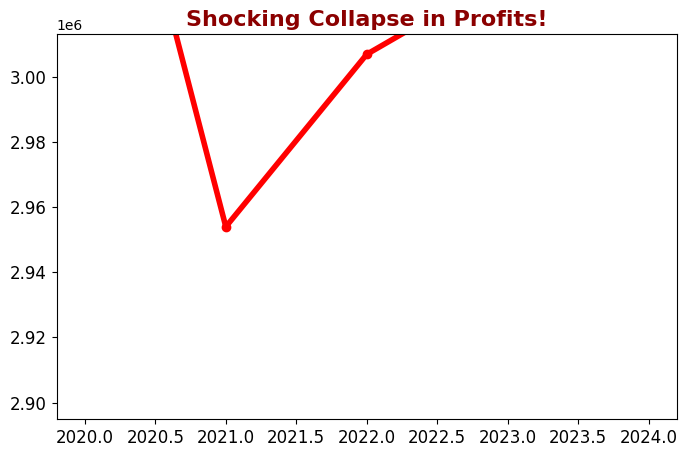

In [3]:
plt.figure(figsize=(8,5))
subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()

# Wrong variable for title, truncated y-axis, misleading color & framing
plt.plot(subset["Year"], subset["Sales"], color="red", linewidth=4, marker="o")
plt.ylim(subset["Sales"].min() * 0.98, subset["Sales"].min() * 1.02)  # extreme truncation
plt.title("Shocking Collapse in Profits!", fontsize=16, fontweight="bold", color="darkred")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()


### Write your notes about bad chart #1 here:
1. The years on the x-axis have decimal points. Decimal points aren't needed.
2. The y-axis starts at 2.90. It should start at 0.
3. What is with the 1e6 near the top of the y-axis?
4. I don't see any labels for either the x or y axis.
5. The title should be changed to ask a question, or it needs to be re-written in such as way that we can clearly understand the story that is being told with this visualization. 

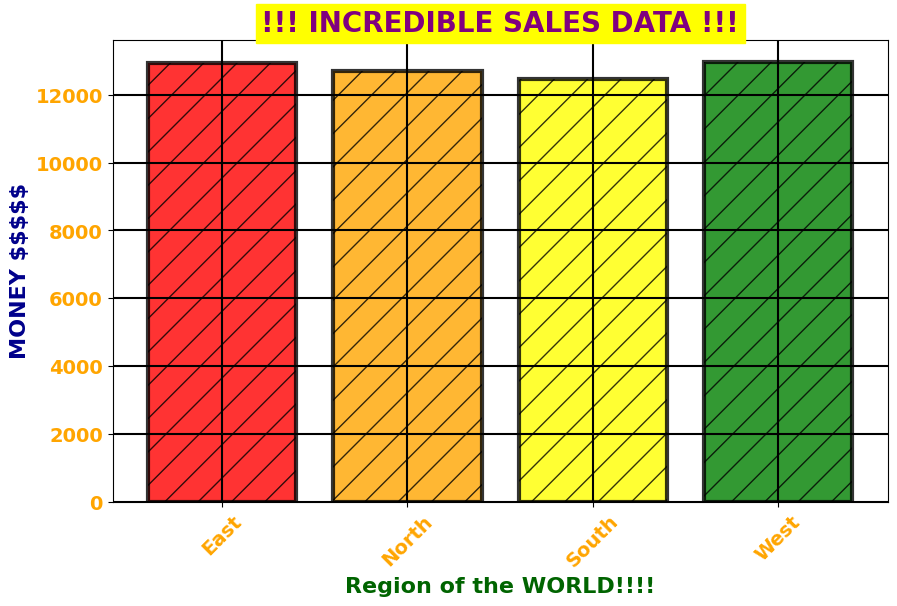

In [4]:
plt.figure(figsize=(10,6))
avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()

colors = ["red","orange","yellow","green","blue","purple"]

plt.bar(avg_sales["Region"], avg_sales["Sales"], 
        color=colors, edgecolor="black", linewidth=3, hatch="/", alpha=0.8)
plt.title("!!! INCREDIBLE SALES DATA !!!", fontsize=20, fontweight="bold", color="purple", backgroundcolor="yellow")
plt.grid(True, which='both', color='black', linestyle='-', linewidth=1.5)
plt.xlabel("Region of the WORLD!!!!", fontsize=16, fontweight="bold", color="darkgreen")
plt.ylabel("MONEY $$$$$", fontsize=16, fontweight="bold", color="darkblue")
plt.xticks(rotation=45, fontsize=14, fontweight="bold", color="orange")
plt.yticks(fontsize=14, fontweight="bold", color="orange")
plt.show()


### Write your notes about bad chart #2 here:
1. We need to change the title to better reflect the story that the visualization is trying to tell us.
2. The rainbow colors are distracting. 
3. The labels for both the x-axis and y-axis need to be changed so that the exclamation points or money signs aren't included.
4. Change the font color for the x and y axis labels. The orange color makes the labels hard to read.  
5. The gridlines within the bar plot need to be removed. 

## Step 3: Your Turn – Make It Right

Now it’s your turn to fix things.  

- Start by thinking about a question you want to answer with this dataset.  
- Choose a visualization type that matches your question and the data structure.  
- Apply the best practices from our lessons: clear labeling, appropriate scale, purposeful color, simplicity, and accessibility.  
- Be honest - don’t manipulate the chart to make a point that the data doesn’t support.  

When you’re done, add your chart(s) below. You may create more than one if it helps tell the story better.  


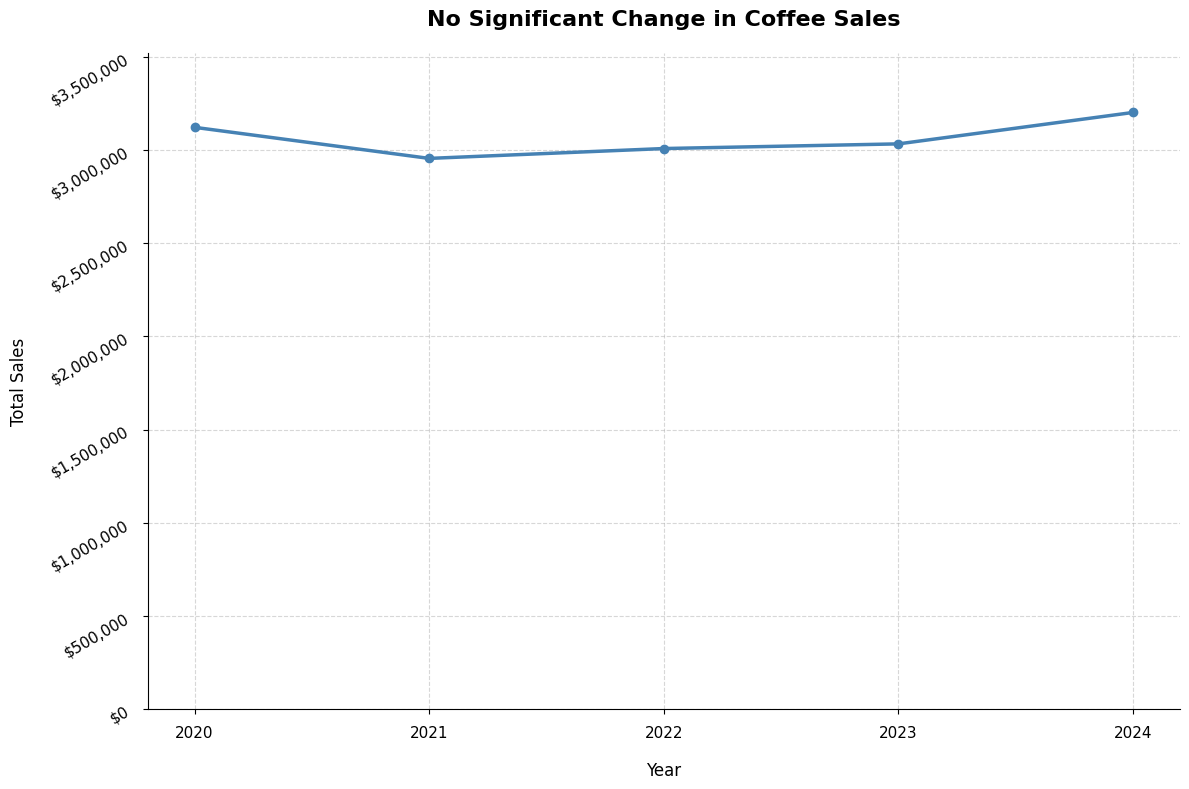

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,8))

subset = coffee_df.groupby("Year")["Sales"].sum().reset_index()

plt.plot(
    subset["Year"],
    subset["Sales"],
    color="steelblue",
    linewidth=2.5,
    marker="o"
)

plt.ylim(0, subset["Sales"].max() * 1.1)

plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('${x:,.0f}')
)

plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('{x:.0f}')
)

plt.title("No Significant Change in Coffee Sales", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("Year", fontsize=12, labelpad=15)
plt.ylabel("Total Sales", fontsize=12, labelpad=15)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=30)

plt.tick_params(axis="x", pad=8)
plt.tick_params(axis="y", pad=8)

plt.grid(True, linestyle="--", alpha=0.5)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

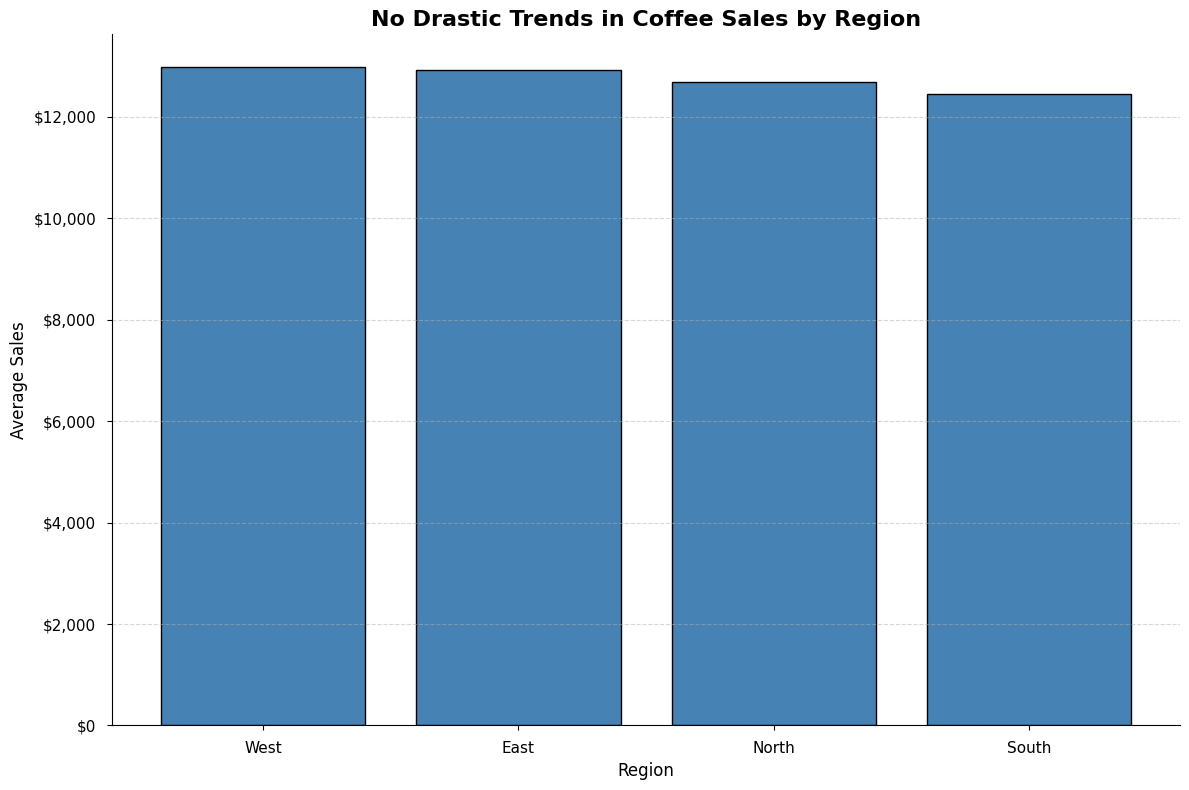

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(12,8))

avg_sales = coffee_df.groupby("Region")["Sales"].mean().reset_index()
avg_sales = avg_sales.sort_values("Sales", ascending=False)

plt.bar(
    avg_sales["Region"],
    avg_sales["Sales"],
    color="steelblue",
    edgecolor="black",
    linewidth=1
)

plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('${x:,.0f}')
)

plt.title("No Drastic Trends in Coffee Sales by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Average Sales", fontsize=12)

plt.xticks(ha="center", fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tick_params(axis="x", pad=8)
plt.tick_params(axis="y", pad=8)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()